In [6]:
import cv2
import matplotlib.pyplot as plt
import torch

In [8]:
print(image.shape)

(705, 630, 3)


In [9]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

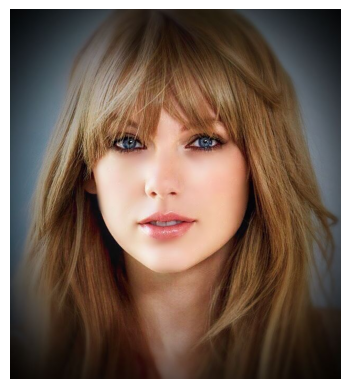

In [10]:
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [11]:
print(image_rgb[100][100])

[74 89 96]


In [12]:
tensor = torch.tensor(image_rgb)

print(type(tensor))

<class 'torch.Tensor'>


In [13]:
print(tensor.shape)

torch.Size([705, 630, 3])


In [14]:
device = torch.device("cuda")

tensor = tensor.to(device)

print(tensor.device)

cuda:0


In [7]:
image = cv2.imread("../data/sample.jpg")

print(type(image))

<class 'numpy.ndarray'>


In [2]:
import cv2

image = cv2.imread("../data/sample.jpg")

resized = cv2.resize(image, (224, 224))

print("Original Shape:", image.shape)
print("Resized Shape:", resized.shape)

Original Shape: (705, 630, 3)
Resized Shape: (224, 224, 3)


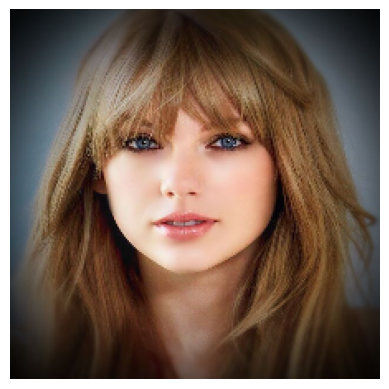

In [3]:
import matplotlib.pyplot as plt

resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

plt.imshow(resized_rgb)
plt.axis("off")
plt.show()

In [4]:
print("Min:", resized.min())
print("Max:", resized.max())

Min: 0
Max: 255


In [5]:
normalized = resized / 255.0

print("Min:", normalized.min())
print("Max:", normalized.max())

Min: 0.0
Max: 1.0


In [6]:
import torch

tensor = torch.tensor(normalized, dtype=torch.float32)

print(type(tensor))
print(tensor.shape)

<class 'torch.Tensor'>
torch.Size([224, 224, 3])


In [7]:
device = torch.device("cuda")

tensor = tensor.to(device)

print(tensor.device)

cuda:0


In [8]:
print(tensor.shape)

torch.Size([224, 224, 3])


In [9]:
tensor = tensor.permute(2, 0, 1)

print(tensor.shape)

torch.Size([3, 224, 224])


In [10]:
tensor = tensor.unsqueeze(0)

print(tensor.shape)

torch.Size([1, 3, 224, 224])


In [11]:
import torchvision.models as models

model = models.resnet18(weights="DEFAULT")

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\hp/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [12]:
output = model(tensor)

print(output.shape)

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

In [13]:
model = model.to("cuda")

In [14]:
output = model(tensor)

print(output.shape)

torch.Size([1, 1000])


In [15]:
predicted_class = output.argmax(dim=1)

print(predicted_class)

tensor([463], device='cuda:0')
